# 03-2. 조건 기반 출시 전 체크리스트 LLM 생성

이 노트북은 `03-1`에서 만든 CSV 4개를 불러와서, 개발자가 입력한 조건에 맞는 **출시 전 점검 체크리스트**를 LLM으로 생성한다.

## 역할

1. 개발자 조건을 입력한다.
2. 조건에 맞는 게임과 반복 이슈 근거를 확인한다.
3. 체크리스트 생성 전에 표와 그래프로 근거를 먼저 살펴본다.
4. Steam 태그 DNA 정보를 보조 근거로 확인한다.
5. LLM으로 상/중/하 우선순위 체크리스트를 만든다.
6. 결과는 저장하지 않고 노트북 화면에 표 형태로 출력한다.

## 사용 데이터

- `prelaunch_game_base.csv`
- `prelaunch_issue_repeat_summary.csv`
- `prelaunch_condition_issue_summary.csv`
- `prelaunch_checklist_evidence_base.csv`
- `steam_indie_games_graded.csv`
  - 조원 EDA에서 사용한 성과 등급 기반 Steam 태그 DNA 참고 데이터

## 해석 기준

이 노트북은 리뷰 수가 많은 게임에서 많이 나온 이슈보다, **여러 게임에서 반복적으로 나타난 이슈**를 더 중요하게 본다.
Steam 태그 DNA는 “이 태그를 넣으면 성공한다”는 의미가 아니라, 입력한 Steam 태그가 성과 상위권 게임에서도 얼마나 나타나는지 보는 보조 참고 정보다.


# 0. 환경설정

In [1]:
# ============================================================
# 기본 라이브러리
# ============================================================
import os
import re
import ast
import json
import platform
from pathlib import Path
from datetime import datetime
from typing import List, Literal

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# ============================================================
# LLM / Pydantic 관련 라이브러리
# ============================================================
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from pydantic_ai import Agent
from pydantic_ai.models.google import GoogleModel, GoogleModelSettings
from pydantic_ai.providers.google import GoogleProvider

# ============================================================
# 한글 폰트 / 출력 옵션
# ============================================================
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (10, 5)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 200)

# 1. 기본 설정

In [2]:
# ============================================================
# 프로젝트 경로 설정
# ============================================================
ROOT = Path.cwd()

# Jupyter 실행 위치가 하위 폴더일 수 있으므로,
# data/preprocessed 폴더가 보일 때까지 상위 폴더를 탐색한다.
if not (ROOT / "data" / "preprocessed").exists():
    for parent in ROOT.parents:
        if (parent / "data" / "preprocessed").exists():
            ROOT = parent
            break

# ============================================================
# 03-1에서 생성한 CSV 폴더
# ============================================================
RUN_NAME = "main_allgames_d0-d30"

DATA_DIR = ROOT / "data" / "outputs" / RUN_NAME / "prelaunch_checklist_data"

GAME_BASE_PATH = DATA_DIR / "prelaunch_game_base.csv"
ISSUE_REPEAT_PATH = DATA_DIR / "prelaunch_issue_repeat_summary.csv"
CONDITION_ISSUE_PATH = DATA_DIR / "prelaunch_condition_issue_summary.csv"
EVIDENCE_BASE_PATH = DATA_DIR / "prelaunch_checklist_evidence_base.csv"

# ============================================================
# 조원 EDA 기반 Steam 태그 DNA 참고 데이터
# ============================================================
# steam_indie_games_graded.csv에는 performance_grade, scale_grade, satisfaction_grade가 들어 있다.
# 이 파일을 이용해서 사용자가 입력한 Steam 태그가 성과 상위권 게임에서 얼마나 자주 나타나는지 참고한다.

GRADED_GAME_PATH = ROOT / "data" / "preprocessed" / "steam_indie_games_graded.csv"

print("DATA_DIR:", DATA_DIR)
print("GRADED_GAME_PATH:", GRADED_GAME_PATH)

DATA_DIR: c:\Users\joon5\Documents\github\steam-indie-game-analysis\data\outputs\main_allgames_d0-d30\prelaunch_checklist_data
GRADED_GAME_PATH: c:\Users\joon5\Documents\github\steam-indie-game-analysis\data\preprocessed\steam_indie_games_graded.csv


In [3]:
# ============================================================
# LLM 실행 여부
# ============================================================
# False: LLM 호출 없이 조건 필터링, 프롬프트, 태그 DNA만 확인한다.
# True : 실제 LLM을 호출해서 체크리스트를 생성한다.

RUN_CHECKLIST_LLM = True

# ============================================================
# 개발자 입력 조건
# ============================================================
# 나중에는 사용자가 입력하는 값이라고 생각하면 된다.
# 지금은 테스트용 조건을 직접 입력한다.

USER_CONDITION = {
    "genres": ["Action"],
    "price_group": "10-20",
    "steam_tags": ["Roguelike", "Pixel Graphics"],
    "steam_tag_match": "any",   # "any": 태그 중 하나라도 포함 / "all": 태그를 모두 포함
    "play_style": "Single-player 중심"
}

# ============================================================
# 프롬프트에 넣을 근거 데이터 개수
# ============================================================
TOP_N_EVIDENCE_PER_CONDITION = 8
TOP_N_OVERALL_ISSUES = 8
MAX_EVIDENCE_ROWS_FOR_PROMPT = 40

# ============================================================
# LLM 호출 설정
# ============================================================
MAX_RETRIES = 3
TEMPERATURE = 0.2

print("RUN_CHECKLIST_LLM:", RUN_CHECKLIST_LLM)
print("USER_CONDITION:")
print(json.dumps(USER_CONDITION, ensure_ascii=False, indent=2))

RUN_CHECKLIST_LLM: True
USER_CONDITION:
{
  "genres": [
    "Action"
  ],
  "price_group": "10-20",
  "steam_tags": [
    "Roguelike",
    "Pixel Graphics"
  ],
  "steam_tag_match": "any",
  "play_style": "Single-player 중심"
}


# 2. Vertex AI / PydanticAI 설정

In [4]:
# ============================================================
# Vertex AI 설정
# ============================================================
# 03_run_llm_allgames_analysi.ipynb와 비슷한 방식으로 구성한다.

load_dotenv()

GOOGLE_CLOUD_PROJECT = os.getenv("GOOGLE_CLOUD_PROJECT")
GOOGLE_CLOUD_LOCATION = os.getenv("GOOGLE_CLOUD_LOCATION", "us-central1")
GEMINI_MODEL = os.getenv("GEMINI_MODEL", "gemini-2.0-flash-001")

provider = None
vertex_model = None

if GOOGLE_CLOUD_PROJECT:
    provider = GoogleProvider(
        vertexai=True,
        project=GOOGLE_CLOUD_PROJECT,
        location=GOOGLE_CLOUD_LOCATION,
    )
    vertex_model = GoogleModel(GEMINI_MODEL, provider=provider)

print("GOOGLE_CLOUD_PROJECT:", GOOGLE_CLOUD_PROJECT)
print("GOOGLE_CLOUD_LOCATION:", GOOGLE_CLOUD_LOCATION)
print("GEMINI_MODEL:", GEMINI_MODEL)
print("Vertex model 생성 여부:", "O" if vertex_model is not None else "X")

GOOGLE_CLOUD_PROJECT: gen-lang-client-0587784564
GOOGLE_CLOUD_LOCATION: global
GEMINI_MODEL: gemini-3.1-flash-lite-preview
Vertex model 생성 여부: O


# 3. 공통 함수

In [5]:
# ============================================================
# JSON 변환 보조 함수
# ============================================================

def to_serializable(obj):
    """Pydantic, pandas, numpy 값을 기본 타입으로 바꾼다."""
    if isinstance(obj, BaseModel):
        return to_serializable(obj.model_dump())
    if isinstance(obj, dict):
        return {k: to_serializable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_serializable(v) for v in obj]
    if isinstance(obj, tuple):
        return [to_serializable(v) for v in obj]
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return None if np.isnan(obj) else float(obj)
    if isinstance(obj, np.bool_):
        return bool(obj)
    if isinstance(obj, pd.Timestamp):
        return obj.isoformat()
    if isinstance(obj, datetime):
        return obj.isoformat()
    try:
        if pd.isna(obj):
            return None
    except Exception:
        pass
    return obj


# ============================================================
# 문자열 검색 함수
# ============================================================

def text_contains_any(text, values):
    text = str(text).lower()
    values = [str(v).lower() for v in values if str(v).strip()]
    return any(v in text for v in values)


def text_contains_all(text, values):
    text = str(text).lower()
    values = [str(v).lower() for v in values if str(v).strip()]
    return all(v in text for v in values)


# ============================================================
# Steam 태그 정리 함수
# ============================================================

def normalize_tag_name(tag):
    """Rogue-like, Roguelike처럼 표기가 달라도 비교할 수 있게 간단히 정규화한다."""
    tag = str(tag).lower()
    tag = re.sub(r"[^a-z0-9가-힣]", "", tag)
    return tag


def parse_tag_names(value):
    """tags 컬럼을 태그명 리스트로 바꾼다."""
    if pd.isna(value):
        return []

    text = str(value).strip()
    if text == "":
        return []

    try:
        parsed = json.loads(text.replace("'", '"'))
    except Exception:
        try:
            parsed = ast.literal_eval(text)
        except Exception:
            parsed = None

    if isinstance(parsed, dict):
        return list(parsed.keys())
    if isinstance(parsed, list):
        return [str(x) for x in parsed]

    return [x.strip() for x in text.split(",") if x.strip()]


# ============================================================
# 프롬프트용 텍스트 표 생성 함수
# ============================================================

def df_to_text_table(df, columns, max_rows=20):
    """tabulate 없이 LLM 프롬프트에 넣을 간단 텍스트 표를 만든다."""
    small = df[columns].head(max_rows).copy()

    if len(small) == 0:
        return "해당 조건에 맞는 근거 데이터가 없습니다."

    lines = []
    header = " | ".join(columns)
    lines.append(header)
    lines.append("-" * len(header))

    for _, row in small.iterrows():
        values = [str(row.get(col, "")) for col in columns]
        lines.append(" | ".join(values))

    return "\n".join(lines)


# ============================================================
# 우선순위 정렬 함수
# ============================================================

def add_priority_order(df, priority_col="priority_level"):
    order_map = {"상": 1, "중": 2, "하": 3}
    out = df.copy()
    out["priority_order"] = out[priority_col].map(order_map).fillna(9)
    return out

# 3-1. 출력 함수 모음

아래 함수들은 노트북 화면에 표와 그래프를 보기 좋게 출력하기 위한 함수다.  
계산 로직과 출력 로직을 분리하기 위해, 이후 셀에서는 함수를 호출하는 방식으로만 출력한다.

In [6]:
# ============================================================
# 출력 함수 모음
# ============================================================
# 목적:
# 계산 로직과 출력 로직을 분리한다.
# 14번에서는 display_pre_checklist_dashboard()만 호출하고,
# 실제 표/그래프 출력은 아래 함수들이 담당한다.
#
# 수정 포인트:
# - 체크리스트 생성 전 화면에서 긍정 요소 그래프와 부정 요소 그래프가 모두 나오도록 정리했다.
# - 가격대별 / Steam 태그별 / 플레이 방식별 비교도 긍정·부정 지표를 모두 확인할 수 있게 했다.


# ------------------------------------------------------------
# 기본 출력 함수
# ------------------------------------------------------------
def show_title(title, description=""):
    """섹션 제목을 출력한다."""
    display(Markdown(f"## {title}"))
    if description:
        display(Markdown(description))


def style_table(df, max_rows=30):
    """일반 표를 보고서처럼 출력한다."""
    view_df = df.head(max_rows).copy()

    if len(view_df) == 0:
        print("출력할 데이터가 없습니다.")
        return

    styled = (
        view_df
        .style
        .hide(axis="index")
        .set_properties(**{
            "text-align": "left",
            "white-space": "pre-wrap",
            "vertical-align": "top",
            "font-size": "13px",
            "line-height": "1.5",
        })
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("font-weight", "bold"),
                    ("background-color", "#f2f2f2"),
                    ("border", "1px solid #cccccc"),
                    ("padding", "8px"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("border", "1px solid #dddddd"),
                    ("padding", "8px"),
                ],
            },
            {
                "selector": "table",
                "props": [
                    ("border-collapse", "collapse"),
                    ("width", "100%"),
                ],
            },
        ])
    )

    display(styled)


def show_analysis_guide(title, purpose="", how_to_read="", checklist_use=""):
    """분석 표/그래프를 출력하기 전에 이 분석이 무엇인지 설명한다."""
    display(Markdown(f"## {title}"))

    guide_rows = []

    if purpose:
        guide_rows.append({"구분": "분석 목적", "설명": purpose})
    if how_to_read:
        guide_rows.append({"구분": "해석 기준", "설명": how_to_read})
    if checklist_use:
        guide_rows.append({"구분": "체크리스트 연결", "설명": checklist_use})

    if guide_rows:
        style_table(pd.DataFrame(guide_rows), max_rows=5)


def style_checklist_table(df):
    """체크리스트 전용 표 스타일이다."""
    if len(df) == 0:
        print("출력할 체크리스트가 없습니다.")
        return

    styled = (
        df
        .style
        .hide(axis="index")
        .set_properties(**{
            "text-align": "left",
            "white-space": "pre-wrap",
            "vertical-align": "top",
            "font-size": "13px",
            "line-height": "1.55",
        })
        .set_properties(subset=["우선순위"], **{
            "text-align": "center",
            "font-weight": "bold",
        })
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("font-weight", "bold"),
                    ("background-color", "#f2f2f2"),
                    ("border", "1px solid #cccccc"),
                    ("padding", "8px"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("border", "1px solid #dddddd"),
                    ("padding", "8px"),
                ],
            },
            {
                "selector": "table",
                "props": [
                    ("border-collapse", "collapse"),
                    ("width", "100%"),
                    ("table-layout", "fixed"),
                ],
            },
            {"selector": "th:nth-child(1)", "props": [("width", "12%")]},
            {"selector": "th:nth-child(2)", "props": [("width", "28%")]},
            {"selector": "th:nth-child(3)", "props": [("width", "8% ")]},
            {"selector": "th:nth-child(4)", "props": [("width", "12%")]},
            {"selector": "th:nth-child(5)", "props": [("width", "20%")]},
            {"selector": "th:nth-child(6)", "props": [("width", "20%")]} ,
        ])
    )

    display(styled)


def plot_barh(df, x_col, y_col, title, xlabel, ylabel="", top_n=10):
    """가로 막대그래프를 출력한다."""
    plot_df = df[[x_col, y_col]].dropna().copy()
    plot_df[x_col] = pd.to_numeric(plot_df[x_col], errors="coerce")
    plot_df = plot_df.dropna(subset=[x_col])
    plot_df = plot_df.sort_values(x_col, ascending=False).head(top_n)
    plot_df = plot_df.sort_values(x_col, ascending=True)

    if len(plot_df) == 0:
        print("그래프로 출력할 데이터가 없습니다.")
        return

    plt.figure(figsize=(9, 5))
    plt.barh(plot_df[y_col], plot_df[x_col])
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()


def plot_heatmap_table(rate_df, title, xlabel="이슈", ylabel="조건"):
    """피벗 테이블과 히트맵을 함께 출력한다."""
    clean_df = rate_df.copy()
    clean_df = clean_df.dropna(how="all")

    if clean_df.empty:
        print(f"{title}: 히트맵으로 출력할 데이터가 없습니다.")
        return

    show_title(title)
    style_table(clean_df.round(1).reset_index(), max_rows=30)

    plt.figure(figsize=(max(8, len(clean_df.columns) * 1.0), max(4, len(clean_df) * 0.55)))
    sns.heatmap(clean_df, annot=True, fmt=".1f", cmap="Blues")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 조건 확인 출력
# ------------------------------------------------------------
def display_condition_summary(user_condition, matched_game_count, matched_review_count, matched_games):
    """사용자 조건과 조건에 맞는 게임 예시를 출력한다."""
    show_analysis_guide(
        "사용자 입력 조건 확인",
        purpose="개발자가 입력한 장르·가격대·Steam 태그·플레이 방식 조건을 확인한다.",
        how_to_read="조건에 맞는 게임 수와 리뷰 수가 충분한지 먼저 확인한다. 표본이 너무 적으면 결과를 강하게 일반화하지 않는다.",
        checklist_use="LLM이 체크리스트를 만들 때 현재 조건의 근거가 충분한지 판단하는 기본 정보로 사용한다."
    )

    condition_rows = [
        {"항목": "장르", "값": ", ".join(user_condition.get("genres", []))},
        {"항목": "가격대", "값": user_condition.get("price_group", "")},
        {"항목": "Steam 태그", "값": ", ".join(user_condition.get("steam_tags", []))},
        {"항목": "Steam 태그 매칭", "값": user_condition.get("steam_tag_match", "any")},
        {"항목": "플레이 방식", "값": user_condition.get("play_style", "")},
        {"항목": "조건에 맞는 게임 수", "값": f"{matched_game_count:,}개"},
        {"항목": "조건에 맞는 분석 리뷰 수", "값": f"{matched_review_count:,}개"},
    ]

    style_table(pd.DataFrame(condition_rows), max_rows=20)

    show_analysis_guide(
        "조건에 맞는 게임 예시",
        purpose="입력한 조건으로 실제 어떤 게임들이 선택되었는지 확인한다.",
        how_to_read="게임명, 가격대, 플레이 방식, 리뷰 수를 보고 조건 필터가 의도대로 적용되었는지 점검한다.",
        checklist_use="조건에 맞는 게임 풀이 너무 좁거나 이상하면, LLM 체크리스트도 참고용으로만 해석해야 한다."
    )
    sample_cols = ["appid", "game_name", "price_group", "play_style", "review_count"]
    sample_cols = [col for col in sample_cols if col in matched_games.columns]
    style_table(matched_games[sample_cols].head(10), max_rows=10)


# ------------------------------------------------------------
# 조건 기반 이슈 요약 함수
# ------------------------------------------------------------
def make_selected_issue_overview(selected_evidence):
    """선택된 조건 근거를 이슈 단위로 요약한다.

    주의:
    - 긍정 요소 그래프가 빠지지 않도록 '긍정 칭찬'은 제거하지 않는다.
    - '기타'만 제외한다.
    - 여러 조건에서 같은 이슈가 반복될 수 있으므로, 이슈별 최대값을 대표값으로 사용한다.
    """
    temp = selected_evidence.copy()
    temp = temp[~temp["issue_name_kor"].isin(["기타"])]

    overview = (
        temp
        .groupby("issue_name_kor")
        .agg(
            issue_game_count=("issue_game_count", "max"),
            issue_game_ratio=("issue_game_ratio", "max"),
            positive_game_count=("positive_game_count", "max"),
            negative_game_count=("negative_game_count", "max"),
            high_urgency_game_count=("high_urgency_game_count", "max"),
            priority_level=("priority_level", "first"),
        )
        .reset_index()
    )

    source = (
        temp
        .assign(source_condition=temp["condition_type"].astype(str) + " | " + temp["condition_value"].astype(str))
        .groupby("issue_name_kor")["source_condition"]
        .apply(lambda x: ", ".join(sorted(set(x))))
        .reset_index(name="source_conditions")
    )

    overview = overview.merge(source, on="issue_name_kor", how="left")
    overview = add_priority_order(overview)
    return overview


def make_positive_issue_view(overview, top_n=10):
    """긍정 요소 TOP 표를 만든다."""
    positive_df = overview[overview["positive_game_count"] > 0].copy()
    positive_df = positive_df.sort_values(
        ["positive_game_count", "issue_game_count", "issue_game_ratio"],
        ascending=False,
    ).head(top_n)

    positive_view = positive_df[[
        "issue_name_kor", "positive_game_count", "issue_game_count", "issue_game_ratio", "source_conditions"
    ]].rename(columns={
        "issue_name_kor": "긍정 요소",
        "positive_game_count": "긍정 발생 게임 수",
        "issue_game_count": "전체 발생 게임 수",
        "issue_game_ratio": "발생 비율(%)",
        "source_conditions": "근거 조건",
    })

    return positive_df, positive_view


def make_negative_issue_view(overview, top_n=10):
    """부정 리스크 TOP 표를 만든다."""
    negative_df = overview[overview["negative_game_count"] > 0].copy()
    negative_df = negative_df.sort_values(
        ["negative_game_count", "high_urgency_game_count", "issue_game_count"],
        ascending=False,
    ).head(top_n)

    negative_view = negative_df[[
        "issue_name_kor", "negative_game_count", "high_urgency_game_count", "issue_game_count", "issue_game_ratio", "source_conditions"
    ]].rename(columns={
        "issue_name_kor": "부정 리스크",
        "negative_game_count": "부정 발생 게임 수",
        "high_urgency_game_count": "High urgency 게임 수",
        "issue_game_count": "전체 발생 게임 수",
        "issue_game_ratio": "발생 비율(%)",
        "source_conditions": "근거 조건",
    })

    return negative_df, negative_view


def display_positive_issues(overview):
    """조건 기반 긍정 요소 표와 그래프를 출력한다."""
    positive_df, positive_view = make_positive_issue_view(overview, top_n=10)

    show_analysis_guide(
        "긍정 요소 TOP 10",
        purpose="입력 조건과 비슷한 게임에서 유저가 좋게 평가한 요소를 확인한다.",
        how_to_read="긍정 발생 게임 수가 많을수록 여러 게임에서 장점으로 반복된 요소로 본다.",
        checklist_use="체크리스트에서는 '출시 전 강화할 요소' 또는 '강점으로 유지할 요소'로 활용한다."
    )
    style_table(positive_view, max_rows=10)
    plot_barh(
        positive_view,
        x_col="긍정 발생 게임 수",
        y_col="긍정 요소",
        title="조건 기반 긍정 요소 TOP 10",
        xlabel="긍정 이슈가 발생한 게임 수",
        ylabel="긍정 요소",
        top_n=10,
    )

    return positive_df


def display_negative_issues(overview):
    """조건 기반 부정 리스크 표와 그래프를 출력한다."""
    negative_df, negative_view = make_negative_issue_view(overview, top_n=10)

    show_analysis_guide(
        "부정 리스크 TOP 10",
        purpose="입력 조건과 비슷한 게임에서 유저가 불만을 느낀 요소를 확인한다.",
        how_to_read="부정 발생 게임 수와 High urgency 게임 수가 많을수록 출시 전에 먼저 점검해야 할 위험 요소로 본다.",
        checklist_use="체크리스트에서는 '출시 전 반드시 확인할 문제 후보'로 활용한다."
    )
    style_table(negative_view, max_rows=10)
    plot_barh(
        negative_view,
        x_col="부정 발생 게임 수",
        y_col="부정 리스크",
        title="조건 기반 부정 리스크 TOP 10",
        xlabel="부정 이슈가 발생한 게임 수",
        ylabel="부정 리스크",
        top_n=10,
    )

    return negative_df


def display_positive_negative_issues(selected_evidence):
    """사용자 조건에서 반복되는 긍정 요소와 부정 리스크를 모두 표/그래프로 출력한다."""
    overview = make_selected_issue_overview(selected_evidence)

    show_analysis_guide(
        "조건 기반 긍정·부정 이슈 요약",
        purpose="입력 조건에서 반복적으로 나타난 긍정 요소와 부정 리스크를 나누어 확인한다.",
        how_to_read="단순 리뷰 수가 아니라, 해당 이슈가 몇 개 게임에서 반복되었는지를 기준으로 본다.",
        checklist_use="긍정 요소는 강화할 항목으로, 부정 리스크는 점검할 항목으로 연결한다."
    )

    positive_df = display_positive_issues(overview)
    negative_df = display_negative_issues(overview)

    return overview, positive_df, negative_df


# ------------------------------------------------------------
# 조건별 히트맵 데이터 함수
# ------------------------------------------------------------
def make_condition_heatmap_data(condition_issue_summary, condition_type, issue_list, value_list=None, metric="negative_game_count"):
    """조건별 이슈 발생 비율 히트맵 데이터를 만든다."""
    temp = condition_issue_summary[
        (condition_issue_summary["condition_type"] == condition_type)
        & (condition_issue_summary["issue_name_kor"].isin(issue_list))
    ].copy()

    if value_list:
        temp = temp[temp["condition_value"].isin(value_list)]

    if len(temp) == 0:
        return pd.DataFrame()

    count_pivot = temp.pivot_table(
        index="condition_value",
        columns="issue_name_kor",
        values=metric,
        fill_value=0,
        aggfunc="max",
    )

    base_count = (
        temp[["condition_value", "condition_game_count"]]
        .drop_duplicates("condition_value")
        .set_index("condition_value")["condition_game_count"]
    )

    rate_pivot = count_pivot.div(base_count, axis=0) * 100
    return rate_pivot


def display_price_group_analysis(condition_issue_summary, positive_issue_list, negative_issue_list):
    """가격대별 긍정 요소와 부정 리스크를 표/히트맵으로 출력한다."""
    show_analysis_guide(
        "가격대별 반복 이슈 비교",
        purpose="주요 긍정 요소와 부정 리스크가 가격대별로 얼마나 반복되는지 비교한다.",
        how_to_read="값은 해당 가격대 게임 중 이슈가 발생한 게임 비율이다. 입력 가격대가 다른 가격대보다 어떤 강점/리스크를 가지는지 확인한다.",
        checklist_use="가격대에 맞는 콘텐츠 분량, 완성도, 가격 대비 가치 점검 질문을 만드는 데 사용한다."
    )

    price_order = ["free", "0-5", "5-10", "10-20", "20-40", "40+"]

    if positive_issue_list:
        positive_rate_df = make_condition_heatmap_data(
            condition_issue_summary=condition_issue_summary,
            condition_type="price_group",
            issue_list=positive_issue_list,
            metric="positive_game_count",
        )
        positive_rate_df = positive_rate_df.reindex([x for x in price_order if x in positive_rate_df.index])
        plot_heatmap_table(
            positive_rate_df,
            title="가격대별 주요 긍정 요소 발생 비율(%)",
            xlabel="긍정 요소",
            ylabel="가격대",
        )

    if negative_issue_list:
        negative_rate_df = make_condition_heatmap_data(
            condition_issue_summary=condition_issue_summary,
            condition_type="price_group",
            issue_list=negative_issue_list,
            metric="negative_game_count",
        )
        negative_rate_df = negative_rate_df.reindex([x for x in price_order if x in negative_rate_df.index])
        plot_heatmap_table(
            negative_rate_df,
            title="가격대별 주요 부정 리스크 발생 비율(%)",
            xlabel="부정 리스크",
            ylabel="가격대",
        )


def display_steam_tag_issue_analysis(condition_issue_summary, positive_issue_list, negative_issue_list, user_condition):
    """입력 Steam 태그별 긍정 요소와 부정 리스크를 표/히트맵으로 출력한다."""
    steam_tags = user_condition.get("steam_tags", [])

    show_analysis_guide(
        "Steam 태그별 반복 이슈 비교",
        purpose="입력한 Steam 태그를 가진 게임들에서 어떤 긍정 요소와 부정 리스크가 반복되는지 확인한다.",
        how_to_read="각 태그별로 이슈 발생 비율을 비교한다. 태그는 장르보다 더 세부적인 기대 요소를 반영한다.",
        checklist_use="예를 들어 Roguelike 태그라면 반복 플레이, 난이도, 밸런스 같은 점검 질문을 강화하는 근거가 된다."
    )

    if positive_issue_list:
        tag_positive_df = make_condition_heatmap_data(
            condition_issue_summary=condition_issue_summary,
            condition_type="steam_tag",
            issue_list=positive_issue_list,
            value_list=steam_tags,
            metric="positive_game_count",
        )
        plot_heatmap_table(
            tag_positive_df,
            title="입력 Steam 태그별 주요 긍정 요소 발생 비율(%)",
            xlabel="긍정 요소",
            ylabel="Steam 태그",
        )

    if negative_issue_list:
        tag_negative_df = make_condition_heatmap_data(
            condition_issue_summary=condition_issue_summary,
            condition_type="steam_tag",
            issue_list=negative_issue_list,
            value_list=steam_tags,
            metric="negative_game_count",
        )
        plot_heatmap_table(
            tag_negative_df,
            title="입력 Steam 태그별 주요 부정 리스크 발생 비율(%)",
            xlabel="부정 리스크",
            ylabel="Steam 태그",
        )


def display_play_style_analysis(condition_issue_summary, positive_issue_list, negative_issue_list):
    """플레이 방식별 긍정 요소와 부정 리스크를 표/히트맵으로 출력한다."""
    show_analysis_guide(
        "플레이 방식별 반복 이슈 비교",
        purpose="싱글 중심 게임과 멀티/협동 요소 포함 게임에서 반복되는 긍정 요소와 부정 리스크 차이를 확인한다.",
        how_to_read="플레이 방식별 이슈 발생 비율을 비교해 어떤 구조에서 어떤 강점/문제가 더 자주 나타나는지 본다.",
        checklist_use="싱글 게임은 콘텐츠 흐름과 몰입감, 멀티/협동 게임은 매칭·동기화·협동 경험 같은 점검 항목으로 연결할 수 있다."
    )

    if positive_issue_list:
        play_positive_df = make_condition_heatmap_data(
            condition_issue_summary=condition_issue_summary,
            condition_type="play_style",
            issue_list=positive_issue_list,
            metric="positive_game_count",
        )
        plot_heatmap_table(
            play_positive_df,
            title="플레이 방식별 주요 긍정 요소 발생 비율(%)",
            xlabel="긍정 요소",
            ylabel="플레이 방식",
        )

    if negative_issue_list:
        play_negative_df = make_condition_heatmap_data(
            condition_issue_summary=condition_issue_summary,
            condition_type="play_style",
            issue_list=negative_issue_list,
            metric="negative_game_count",
        )
        plot_heatmap_table(
            play_negative_df,
            title="플레이 방식별 주요 부정 리스크 발생 비율(%)",
            xlabel="부정 리스크",
            ylabel="플레이 방식",
        )


# ------------------------------------------------------------
# 태그 DNA 출력 함수
# ------------------------------------------------------------
def display_tag_dna(tag_dna_summary):
    """조원 EDA 기반 Steam 태그 DNA 참고 정보를 출력한다."""
    show_analysis_guide(
        "Steam 태그 DNA 참고 정보",
        purpose="조원 EDA에서 사용한 방식처럼, 입력한 Steam 태그가 성과 상위권 게임에서도 얼마나 나타나는지 확인한다.",
        how_to_read="HH/HM/MH는 성과가 비교적 좋은 게임 그룹을 뜻한다. 상위권 비율은 태그의 참고 특성일 뿐 성공 보장으로 해석하지 않는다.",
        checklist_use="태그 자체의 성공 가능성을 말하는 용도가 아니라, 해당 태그를 가진 게임의 기대 요소와 점검 방향을 보조적으로 해석하는 데 사용한다."
    )

    cols = [
        "input_steam_tag", "matched_steam_tag", "total_game_count",
        "high_high_game_count", "high_mid_game_count", "mid_high_game_count",
        "top_tier_game_count", "top_tier_ratio", "tag_dna_note"
    ]
    cols = [col for col in cols if col in tag_dna_summary.columns]

    view_df = tag_dna_summary[cols].copy().rename(columns={
        "input_steam_tag": "입력 태그",
        "matched_steam_tag": "매칭 태그",
        "total_game_count": "전체 게임 수",
        "high_high_game_count": "HH 게임 수",
        "high_mid_game_count": "HM 게임 수",
        "mid_high_game_count": "MH 게임 수",
        "top_tier_game_count": "상위권 게임 수",
        "top_tier_ratio": "상위권 비율(%)",
        "tag_dna_note": "해석 메모",
    })

    style_table(view_df, max_rows=20)

    if "top_tier_ratio" in tag_dna_summary.columns and "input_steam_tag" in tag_dna_summary.columns:
        plot_barh(
            tag_dna_summary,
            x_col="top_tier_ratio",
            y_col="input_steam_tag",
            title="입력 Steam 태그별 성과 상위권 비율",
            xlabel="성과 상위권 비율(%)",
            ylabel="Steam 태그",
            top_n=20,
        )


# ------------------------------------------------------------
# 전체 기준 반복 이슈 출력 함수
# ------------------------------------------------------------
def display_overall_issues(overall_issues):
    """전체 게임 기준 긍정 요소와 부정 리스크를 출력한다."""
    show_analysis_guide(
        "전체 게임 기준 반복 이슈",
        purpose="전체 분석 대상 게임에서 공통적으로 많이 반복된 긍정 요소와 부정 리스크를 확인한다.",
        how_to_read="조건별 이슈가 전체 게임에서도 흔한 문제인지, 특정 조건에서만 두드러지는 문제인지 비교하는 기준선으로 본다.",
        checklist_use="LLM이 조건별 이슈를 과대해석하지 않도록 전체 기준과 비교하는 보조 근거로 사용한다."
    )

    base_cols = [
        "issue_name_kor", "issue_game_count", "issue_game_ratio",
        "positive_game_count", "negative_game_count", "high_urgency_game_count", "priority_level"
    ]
    base_cols = [col for col in base_cols if col in overall_issues.columns]

    view_df = overall_issues[base_cols].copy().rename(columns={
        "issue_name_kor": "이슈",
        "issue_game_count": "발생 게임 수",
        "issue_game_ratio": "발생 비율(%)",
        "positive_game_count": "긍정 발생 게임 수",
        "negative_game_count": "부정 발생 게임 수",
        "high_urgency_game_count": "High urgency 게임 수",
        "priority_level": "우선순위",
    })

    style_table(view_df, max_rows=15)

    overall_positive = overall_issues[overall_issues["positive_game_count"] > 0].copy()
    overall_positive = overall_positive.sort_values("positive_game_count", ascending=False).head(10)
    plot_barh(
        overall_positive,
        x_col="positive_game_count",
        y_col="issue_name_kor",
        title="전체 게임 기준 긍정 요소 TOP 10",
        xlabel="긍정 이슈가 발생한 게임 수",
        ylabel="긍정 요소",
        top_n=10,
    )

    overall_negative = overall_issues[overall_issues["negative_game_count"] > 0].copy()
    overall_negative = overall_negative.sort_values("negative_game_count", ascending=False).head(10)
    plot_barh(
        overall_negative,
        x_col="negative_game_count",
        y_col="issue_name_kor",
        title="전체 게임 기준 부정 리스크 TOP 10",
        xlabel="부정 이슈가 발생한 게임 수",
        ylabel="부정 리스크",
        top_n=10,
    )


# ------------------------------------------------------------
# 체크리스트 생성 전 대시보드 출력 함수
# ------------------------------------------------------------
def display_pre_checklist_dashboard(
    selected_evidence,
    condition_issue_summary,
    overall_issues,
    tag_dna_summary,
    user_condition,
):
    """LLM 체크리스트 생성 전에 필요한 조건 기반 표/그래프를 한 번에 출력한다."""
    show_analysis_guide(
        "체크리스트 생성 전 조건 기반 분석 요약",
        purpose="LLM이 체크리스트를 생성하기 전에, 선택된 조건에서 어떤 근거가 사용되는지 사람이 먼저 확인한다.",
        how_to_read="긍정 요소, 부정 리스크, 가격대, Steam 태그, 태그 DNA, 플레이 방식, 전체 기준을 순서대로 확인한다.",
        checklist_use="이 출력 결과가 LLM 프롬프트의 핵심 근거가 되며, 최종 체크리스트의 상·중·하 우선순위 판단에 사용된다."
    )

    overview, positive_df, negative_df = display_positive_negative_issues(selected_evidence)

    positive_issue_list = (
        positive_df.sort_values(
            ["positive_game_count", "issue_game_count", "issue_game_ratio"],
            ascending=False,
        )["issue_name_kor"]
        .head(6)
        .tolist()
    )

    negative_issue_list = (
        negative_df.sort_values(
            ["negative_game_count", "high_urgency_game_count", "issue_game_count"],
            ascending=False,
        )["issue_name_kor"]
        .head(6)
        .tolist()
    )

    if len(positive_issue_list) == 0:
        positive_issue_list = overview.sort_values("positive_game_count", ascending=False)["issue_name_kor"].head(6).tolist()

    if len(negative_issue_list) == 0:
        negative_issue_list = overview.sort_values("negative_game_count", ascending=False)["issue_name_kor"].head(6).tolist()

    display_price_group_analysis(condition_issue_summary, positive_issue_list, negative_issue_list)
    display_steam_tag_issue_analysis(condition_issue_summary, positive_issue_list, negative_issue_list, user_condition)
    display_tag_dna(tag_dna_summary)
    display_play_style_analysis(condition_issue_summary, positive_issue_list, negative_issue_list)
    display_overall_issues(overall_issues)

    return {
        "overview": overview,
        "positive_df": positive_df,
        "negative_df": negative_df,
        "positive_issue_list": positive_issue_list,
        "negative_issue_list": negative_issue_list,
    }


# ------------------------------------------------------------
# LLM 결과 체크리스트 표 출력 함수
# ------------------------------------------------------------
def make_checklist_table(result_dict):
    """LLM 결과를 보고서용 체크리스트 표로 바꾼다."""
    rows = []

    priority_info = [
        ("상", "high_priority"),
        ("중", "mid_priority"),
        ("하", "low_priority"),
    ]

    for priority, key in priority_info:
        items = result_dict.get(key, [])

        for item in items:
            rows.append({
                "구분": item.get("category", ""),
                "체크 질문": item.get("check_question", ""),
                "우선순위": priority,
                "근거 이슈": item.get("evidence_issue", ""),
                "근거": item.get("evidence_summary", ""),
                "확인 방법": item.get("how_to_check", ""),
            })

    checklist_df = pd.DataFrame(rows)

    if len(checklist_df) == 0:
        return checklist_df

    return checklist_df[["구분", "체크 질문", "우선순위", "근거 이슈", "근거", "확인 방법"]]


def display_checklist_result(result_dict):
    """LLM 체크리스트 결과를 표 중심으로 출력한다."""
    show_analysis_guide(
        "출시 전 개발 체크리스트",
        purpose="LLM이 조건 기반 근거를 바탕으로 생성한 최종 출시 전 점검표를 확인한다.",
        how_to_read="체크 질문은 개발자가 출시 전에 실제로 확인해야 하는 항목이며, 우선순위는 상·중·하로 나뉜다.",
        checklist_use="보고서나 발표에서는 이 표를 최종 결과물로 제시하면 된다."
    )

    summary_rows = [
        {"항목": "조건 요약", "내용": result_dict.get("condition_summary", "")},
        {"항목": "데이터 요약", "내용": result_dict.get("data_summary", "")},
        {"항목": "Steam 태그 DNA 참고", "내용": result_dict.get("tag_dna_summary", "")},
    ]
    style_table(pd.DataFrame(summary_rows), max_rows=10)

    checklist_df = make_checklist_table(result_dict)

    if len(checklist_df) == 0:
        print("출력할 체크리스트 항목이 없습니다.")
        return checklist_df

    style_checklist_table(checklist_df)

    priority_count = (
        checklist_df["우선순위"]
        .value_counts()
        .reindex(["상", "중", "하"])
        .fillna(0)
        .astype(int)
        .reset_index()
    )
    priority_count.columns = ["우선순위", "항목 수"]

    plt.figure(figsize=(6, 4))
    plt.bar(priority_count["우선순위"], priority_count["항목 수"])
    plt.title("체크리스트 우선순위별 항목 수")
    plt.xlabel("우선순위")
    plt.ylabel("항목 수")
    plt.tight_layout()
    plt.show()

    cautions = result_dict.get("cautions", [])
    if cautions:
        show_analysis_guide(
            "해석 시 주의사항",
            purpose="LLM 체크리스트를 해석할 때 주의해야 할 한계와 조건을 확인한다.",
            how_to_read="표본 수가 적거나 근거가 약한 조건은 단정적으로 해석하지 않는다.",
            checklist_use="최종 보고서에서 분석 한계 또는 주의사항 문장으로 사용할 수 있다."
        )
        caution_df = pd.DataFrame({"주의사항": cautions})
        style_table(caution_df, max_rows=10)

    final_summary = result_dict.get("final_summary", "")
    if final_summary:
        show_analysis_guide(
            "최종 요약",
            purpose="LLM이 생성한 체크리스트의 핵심 결론을 짧게 확인한다.",
            how_to_read="입력 조건에서 가장 우선적으로 점검해야 할 방향을 요약한 문장으로 읽는다.",
            checklist_use="발표용 마무리 문장이나 보고서 요약에 활용할 수 있다."
        )
        display(Markdown(final_summary))

    return checklist_df


def display_pre_llm_summary(
    matched_game_count,
    matched_review_count,
    selected_evidence,
    tag_dna_summary,
    checklist_prompt,
):
    """LLM 호출 전, 근거가 잘 만들어졌는지 최종 확인한다."""
    show_analysis_guide(
        "LLM 호출 전 최종 확인",
        purpose="LLM을 호출하기 전에 조건에 맞는 근거 데이터가 충분히 준비되었는지 확인한다.",
        how_to_read="게임 수, 리뷰 수, 근거 데이터 수, 태그 DNA 행 수를 보고 근거 부족 여부를 판단한다.",
        checklist_use="근거가 너무 적으면 LLM 호출 전에 조건을 넓히거나 결과를 참고용으로 해석해야 한다."
    )

    summary_df = pd.DataFrame([
        {"항목": "조건에 맞는 게임 수", "값": f"{matched_game_count:,}개"},
        {"항목": "조건에 맞는 분석 리뷰 수", "값": f"{matched_review_count:,}개"},
        {"항목": "선택된 근거 데이터 수", "값": f"{len(selected_evidence):,}개"},
        {"항목": "Steam 태그 DNA 행 수", "값": f"{len(tag_dna_summary):,}개"},
    ])
    style_table(summary_df, max_rows=10)

    show_analysis_guide(
        "프롬프트 미리보기",
        purpose="LLM에게 실제로 전달될 프롬프트 일부를 확인한다.",
        how_to_read="입력 조건, 근거표, 태그 DNA, 출력 형식 지시가 제대로 들어갔는지 확인한다.",
        checklist_use="프롬프트 내용이 어색하면 LLM 결과도 흔들리므로, 실제 호출 전 마지막 점검용으로 사용한다."
    )
    display(Markdown("```text\n" + checklist_prompt[:2500] + "\n```"))


# 4. 데이터 불러오기

In [7]:
# ============================================================
# 03-1에서 만든 CSV 불러오기
# ============================================================

game_base = pd.read_csv(GAME_BASE_PATH)
issue_repeat_summary = pd.read_csv(ISSUE_REPEAT_PATH)
condition_issue_summary = pd.read_csv(CONDITION_ISSUE_PATH)
evidence_base = pd.read_csv(EVIDENCE_BASE_PATH)

graded_games = pd.read_csv(GRADED_GAME_PATH)

# 문자열 컬럼 정리
for df in [game_base, issue_repeat_summary, condition_issue_summary, evidence_base, graded_games]:
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].fillna("").astype(str).str.strip()

print("game_base:", game_base.shape)
print("issue_repeat_summary:", issue_repeat_summary.shape)
print("condition_issue_summary:", condition_issue_summary.shape)
print("evidence_base:", evidence_base.shape)
print("graded_games:", graded_games.shape)

game_base: (151, 15)
issue_repeat_summary: (21, 12)
condition_issue_summary: (3874, 14)
evidence_base: (3302, 13)
graded_games: (9169, 24)


C:\Users\joon5\AppData\Local\Temp\ipykernel_46324\2581022686.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:
C:\Users\joon5\AppData\Local\Temp\ipykernel_46324\2581022686.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guid

# 5. 사용자 조건에 맞는 게임 확인

In [8]:
# ============================================================
# 사용자 조건에 맞는 게임 필터링
# ============================================================
# 이 단계는 LLM이 근거를 해석하기 전에,
# 입력 조건에 해당하는 게임 수가 충분한지 확인하기 위한 작업이다.

matched_games = game_base.copy()

# 장르 조건
genres = USER_CONDITION.get("genres", [])
if genres:
    matched_games = matched_games[
        matched_games["genres_text"].apply(lambda x: text_contains_any(x, genres))
    ]

# 가격대 조건
price_group = USER_CONDITION.get("price_group")
if price_group:
    matched_games = matched_games[matched_games["price_group"] == price_group]

# Steam 태그 조건
steam_tags = USER_CONDITION.get("steam_tags", [])
steam_tag_match = USER_CONDITION.get("steam_tag_match", "any")

if steam_tags:
    if steam_tag_match == "all":
        matched_games = matched_games[
            matched_games["top_steam_tags_text"].apply(lambda x: text_contains_all(x, steam_tags))
        ]
    else:
        matched_games = matched_games[
            matched_games["top_steam_tags_text"].apply(lambda x: text_contains_any(x, steam_tags))
        ]

# 플레이 방식 조건
play_style = USER_CONDITION.get("play_style")
if play_style:
    matched_games = matched_games[matched_games["play_style"] == play_style]

matched_game_count = matched_games["appid"].nunique()
matched_review_count = matched_games["review_count"].sum()

display_condition_summary(
    USER_CONDITION,
    matched_game_count,
    matched_review_count,
    matched_games,
)


## 사용자 입력 조건 확인

구분,설명
분석 목적,개발자가 입력한 장르·가격대·Steam 태그·플레이 방식 조건을 확인한다.
해석 기준,조건에 맞는 게임 수와 리뷰 수가 충분한지 먼저 확인한다. 표본이 너무 적으면 결과를 강하게 일반화하지 않는다.
체크리스트 연결,LLM이 체크리스트를 만들 때 현재 조건의 근거가 충분한지 판단하는 기본 정보로 사용한다.


항목,값
장르,Action
가격대,10-20
Steam 태그,"Roguelike, Pixel Graphics"
Steam 태그 매칭,any
플레이 방식,Single-player 중심
조건에 맞는 게임 수,1개
조건에 맞는 분석 리뷰 수,1개


## 조건에 맞는 게임 예시

구분,설명
분석 목적,입력한 조건으로 실제 어떤 게임들이 선택되었는지 확인한다.
해석 기준,"게임명, 가격대, 플레이 방식, 리뷰 수를 보고 조건 필터가 의도대로 적용되었는지 점검한다."
체크리스트 연결,"조건에 맞는 게임 풀이 너무 좁거나 이상하면, LLM 체크리스트도 참고용으로만 해석해야 한다."


appid,game_name,price_group,play_style,review_count
2668540,Targeosity Horror,10-20,Single-player 중심,1


# 6. 조건별 반복 이슈 근거 선택

In [9]:
# ============================================================
# 사용자 조건에 맞는 condition evidence 선택
# ============================================================
# 여기서는 조건별로 미리 만들어둔 근거표를 가져온다.
# 예: genre=Action, price_group=10-20, steam_tag=Roguelike, play_style=Single-player 중심

selected_parts = []

# 장르 근거
for genre in USER_CONDITION.get("genres", []):
    temp = evidence_base[
        (evidence_base["condition_type"] == "genre")
        & (evidence_base["condition_value"] == genre)
    ].copy()
    selected_parts.append(temp)

# 가격대 근거
price_group = USER_CONDITION.get("price_group")
if price_group:
    temp = evidence_base[
        (evidence_base["condition_type"] == "price_group")
        & (evidence_base["condition_value"] == price_group)
    ].copy()
    selected_parts.append(temp)

# Steam 태그 근거
for steam_tag in USER_CONDITION.get("steam_tags", []):
    temp = evidence_base[
        (evidence_base["condition_type"] == "steam_tag")
        & (evidence_base["condition_value"] == steam_tag)
    ].copy()
    selected_parts.append(temp)

# 플레이 방식 근거
play_style = USER_CONDITION.get("play_style")
if play_style:
    temp = evidence_base[
        (evidence_base["condition_type"] == "play_style")
        & (evidence_base["condition_value"] == play_style)
    ].copy()
    selected_parts.append(temp)

selected_evidence = pd.concat(selected_parts, ignore_index=True)

# 우선순위/발생 비율 기준 정렬
selected_evidence = add_priority_order(selected_evidence)
selected_evidence = selected_evidence.sort_values(
    ["priority_order", "issue_game_ratio", "issue_game_count", "high_urgency_game_count"],
    ascending=[True, False, False, False]
)

# 조건별로 너무 많은 근거가 들어가지 않도록 상위 N개만 사용
selected_evidence = (
    selected_evidence
    .groupby(["condition_type", "condition_value"], group_keys=False)
    .head(TOP_N_EVIDENCE_PER_CONDITION)
    .reset_index(drop=True)
)

selected_evidence_for_prompt = selected_evidence.head(MAX_EVIDENCE_ROWS_FOR_PROMPT).copy()

print("선택된 조건별 근거 데이터:", selected_evidence.shape)


선택된 조건별 근거 데이터: (32, 14)


# 7. 전체 게임 기준 반복 이슈

In [10]:
# ============================================================
# 전체 게임 기준 반복 이슈
# ============================================================
# 조건별 근거만 보면 특정 조건의 특징인지, 전체적으로 흔한 이슈인지 판단하기 어렵다.
# 그래서 전체 기준선 이슈도 함께 프롬프트에 넣는다.

overall_issues = add_priority_order(issue_repeat_summary)
overall_issues = overall_issues.sort_values(
    ["priority_order", "issue_game_ratio", "issue_game_count", "high_urgency_game_count"],
    ascending=[True, False, False, False]
).head(TOP_N_OVERALL_ISSUES)

print("전체 기준 반복 이슈 데이터:", overall_issues.shape)


전체 기준 반복 이슈 데이터: (8, 13)


# 8. Steam 태그 DNA 참고 정보

## Steam 태그 DNA 참고 정보란?

조원 EDA의 태그 DNA 분석은 **입력한 Steam 태그가 성과 상위권 게임에서도 얼마나 자주 나타나는지** 확인하는 보조 분석이다.

이 정보는 체크리스트의 직접 근거가 아니다.  
체크리스트의 직접 근거는 `prelaunch_condition_issue_summary.csv`, `prelaunch_checklist_evidence_base.csv`에 들어 있는 **조건별 반복 이슈**다.

따라서 태그 DNA는 다음처럼 사용한다.

- `Roguelike` 태그가 성과 상위권 게임에서도 자주 보이는지 참고한다.
- 하지만 `Roguelike` 태그를 넣으면 성공한다는 뜻으로 해석하지 않는다.
- LLM은 태그 DNA를 Steam 태그 조건을 이해하는 보조 설명으로만 사용한다.


In [11]:
# ============================================================
# Steam 태그 DNA 참고 정보 생성
# ============================================================
# 사용자가 입력한 Steam 태그가 성과 등급이 높은 게임에서 얼마나 나타나는지 확인한다.
# 이 정보는 체크리스트의 직접 근거가 아니라, Steam 태그 조건 해석용 보조 근거다.

graded_tag_base = graded_games[["appid", "name", "performance_grade", "tags"]].copy()
graded_tag_base["tag_list"] = graded_tag_base["tags"].apply(parse_tag_names)

graded_tag_long = graded_tag_base.explode("tag_list").dropna(subset=["tag_list"]).copy()
graded_tag_long["steam_tag"] = graded_tag_long["tag_list"].astype(str).str.strip()
graded_tag_long = graded_tag_long[graded_tag_long["steam_tag"] != ""]
graded_tag_long["tag_norm"] = graded_tag_long["steam_tag"].apply(normalize_tag_name)

TOP_TIER_GRADES = ["high_high", "high_mid", "mid_high"]

tag_dna_rows = []

for input_tag in USER_CONDITION.get("steam_tags", []):
    input_norm = normalize_tag_name(input_tag)
    matched_tag_rows = graded_tag_long[graded_tag_long["tag_norm"] == input_norm].copy()

    total_game_count = matched_tag_rows["appid"].nunique()
    high_high_game_count = matched_tag_rows.loc[matched_tag_rows["performance_grade"] == "high_high", "appid"].nunique()
    high_mid_game_count = matched_tag_rows.loc[matched_tag_rows["performance_grade"] == "high_mid", "appid"].nunique()
    mid_high_game_count = matched_tag_rows.loc[matched_tag_rows["performance_grade"] == "mid_high", "appid"].nunique()
    top_tier_game_count = matched_tag_rows.loc[matched_tag_rows["performance_grade"].isin(TOP_TIER_GRADES), "appid"].nunique()

    top_tier_ratio = 0
    if total_game_count > 0:
        top_tier_ratio = round(top_tier_game_count / total_game_count * 100, 1)

    matched_tag_name = ""
    if len(matched_tag_rows) > 0:
        matched_tag_name = matched_tag_rows["steam_tag"].mode().iloc[0]

    if total_game_count == 0:
        note = f"'{input_tag}' 태그는 성과 등급 데이터에서 확인되지 않았다."
    else:
        note = (
            f"'{input_tag}' 태그는 성과 등급 데이터에서 {total_game_count}개 게임에 나타났고, "
            f"그중 성과 상위권(HH/HM/MH) 게임은 {top_tier_game_count}개({top_tier_ratio}%)다. "
            f"이는 성공 보장이 아니라 태그 조건 해석용 참고 정보다."
        )

    tag_dna_rows.append({
        "input_steam_tag": input_tag,
        "matched_steam_tag": matched_tag_name,
        "total_game_count": total_game_count,
        "high_high_game_count": high_high_game_count,
        "high_mid_game_count": high_mid_game_count,
        "mid_high_game_count": mid_high_game_count,
        "top_tier_game_count": top_tier_game_count,
        "top_tier_ratio": top_tier_ratio,
        "tag_dna_note": note,
    })

tag_dna_summary = pd.DataFrame(tag_dna_rows)

print("Steam 태그 DNA 참고 데이터:", tag_dna_summary.shape)


Steam 태그 DNA 참고 데이터: (2, 9)


# 9. LLM 출력 스키마 정의

In [12]:
# ============================================================
# 체크리스트 출력 스키마
# ============================================================
# 표로 출력하기 쉽도록 필드명을 체크리스트 표 형태에 맞춘다.

class ChecklistItem(BaseModel):
    priority: Literal["상", "중", "하"] = Field(description="체크리스트 우선순위")
    category: str = Field(description="점검 구분. 예: 기술 안정성, 조작감, 핵심 루프, 난이도, UI/UX, 콘텐츠 분량, 그래픽/사운드, 가격 대비 가치")
    check_question: str = Field(description="출시 전 확인해야 할 질문형 체크 항목. 반드시 질문형으로 작성")
    evidence_issue: str = Field(description="근거가 된 이슈명")
    evidence_summary: str = Field(description="제공된 근거표 기반 요약")
    how_to_check: str = Field(description="개발자가 출시 전에 확인할 수 있는 방법")
    source_conditions: List[str] = Field(description="이 근거가 나온 조건 목록")


class PrelaunchChecklistResult(BaseModel):
    title: str = Field(description="체크리스트 제목")
    condition_summary: str = Field(description="사용자 입력 조건 요약")
    data_summary: str = Field(description="근거 데이터 규모 요약")
    tag_dna_summary: str = Field(description="Steam 태그 DNA 참고 정보 요약")
    high_priority: List[ChecklistItem] = Field(description="상 우선순위 체크리스트")
    mid_priority: List[ChecklistItem] = Field(description="중 우선순위 체크리스트")
    low_priority: List[ChecklistItem] = Field(description="하 우선순위 체크리스트")
    cautions: List[str] = Field(description="해석 시 주의사항")
    final_summary: str = Field(description="전체 요약")


print("체크리스트 출력 스키마 정의 완료")

체크리스트 출력 스키마 정의 완료


# 10. LLM 프롬프트 생성

In [13]:
# ============================================================
# 프롬프트 생성 함수
# ============================================================

def build_checklist_prompt(
    user_condition,
    matched_game_count,
    matched_review_count,
    selected_evidence_df,
    overall_issues_df,
    tag_dna_df,
):
    evidence_cols = [
        "condition_type",
        "condition_value",
        "issue_name_kor",
        "condition_game_count",
        "issue_game_count",
        "issue_game_ratio",
        "positive_game_count",
        "negative_game_count",
        "high_urgency_game_count",
        "priority_level",
        "llm_evidence_text",
    ]

    overall_cols = [
        "issue_name_kor",
        "issue_game_count",
        "issue_game_ratio",
        "negative_game_count",
        "high_urgency_game_count",
        "priority_level",
    ]

    tag_dna_cols = [
        "input_steam_tag",
        "matched_steam_tag",
        "total_game_count",
        "top_tier_game_count",
        "top_tier_ratio",
        "tag_dna_note",
    ]

    evidence_text = df_to_text_table(
        selected_evidence_df,
        columns=evidence_cols,
        max_rows=MAX_EVIDENCE_ROWS_FOR_PROMPT,
    )

    overall_text = df_to_text_table(
        overall_issues_df,
        columns=overall_cols,
        max_rows=TOP_N_OVERALL_ISSUES,
    )

    tag_dna_text = df_to_text_table(
        tag_dna_df,
        columns=tag_dna_cols,
        max_rows=20,
    )

    prompt = f"""
당신은 Steam 인디게임 출시 전 점검을 도와주는 데이터 분석 전문가입니다.

목표:
개발자가 입력한 장르·가격대·Steam 태그·플레이 방식 조건을 바탕으로,
기존 Steam 인디게임의 D0-D30 초기 리뷰 LLM 분석 결과에서 반복된 이슈를 참고하여
출시 전 체크리스트를 생성하세요.

중요한 해석 기준:
- 리뷰 수가 많은 게임에서 많이 나온 이슈보다, 여러 게임에서 반복된 이슈를 더 중요하게 봅니다.
- 제공된 근거표의 issue_game_count, issue_game_ratio, negative_game_count, high_urgency_game_count를 중심으로 판단하세요.
- 태그 수나 리뷰 수만으로 과도하게 단정하지 마세요.
- 근거가 약하면 "참고 수준" 또는 "주의해서 해석"이라고 표현하세요.
- 체크리스트는 반드시 상/중/하 우선순위로 나누세요.
- 근거표에 없는 내용을 새로 지어내지 마세요.
- 체크 질문은 반드시 실제 출시 전에 확인 가능한 질문형 문장으로 작성하세요.
- 예: "크래시, 저장 오류, 진행 불가 버그가 없는가?"
- 예: "초반 30분 안에 게임의 핵심 재미가 드러나는가?"
- 예: "이동, 공격, 회피, 상호작용이 즉각적으로 반응하는가?"

Steam 태그 DNA 참고 기준:
- Steam 태그 DNA는 조원 EDA에서 가져온 보조 관점입니다.
- 성과 상위권 게임에서 특정 Steam 태그가 얼마나 자주 나타나는지 보여줍니다.
- 이것은 "해당 태그를 넣으면 성공한다"는 뜻이 아닙니다.
- 체크리스트의 직접 근거는 반복 이슈 근거표이며, 태그 DNA는 Steam 태그 조건을 해석하는 보조 근거로만 사용하세요.

사용자 입력 조건:
{json.dumps(user_condition, ensure_ascii=False, indent=2)}

조건에 맞는 게임 수:
- 게임 수: {matched_game_count}
- 분석 리뷰 수: {matched_review_count}

조건별 반복 이슈 근거표:
{evidence_text}

전체 게임 기준 반복 이슈:
{overall_text}

Steam 태그 DNA 참고 정보:
{tag_dna_text}

출력 요구:
1. 사용자의 조건을 간단히 요약하세요.
2. 데이터 규모를 간단히 설명하세요.
3. Steam 태그 DNA 참고 정보를 1~2문장으로 요약하세요.
4. 상 우선순위 체크리스트를 작성하세요.
5. 중 우선순위 체크리스트를 작성하세요.
6. 하 우선순위 체크리스트를 작성하세요.
7. 각 항목은 category, check_question, evidence_issue, evidence_summary, how_to_check가 표로 출력되기 좋은 내용이어야 합니다.
8. 마지막에는 해석 시 주의사항을 작성하세요.
"""

    return prompt.strip()


checklist_prompt = build_checklist_prompt(
    user_condition=USER_CONDITION,
    matched_game_count=matched_game_count,
    matched_review_count=matched_review_count,
    selected_evidence_df=selected_evidence_for_prompt,
    overall_issues_df=overall_issues,
    tag_dna_df=tag_dna_summary,
)

print("프롬프트 생성 완료")

프롬프트 생성 완료


# 11. LLM 호출 전 확인

In [14]:
# ============================================================
# LLM 호출 전 최종 확인
# ============================================================
# RUN_CHECKLIST_LLM=False 상태에서도 조건, 근거, 태그 DNA, 프롬프트가 잘 만들어졌는지 확인한다.

display_pre_llm_summary(
    matched_game_count=matched_game_count,
    matched_review_count=matched_review_count,
    selected_evidence=selected_evidence,
    tag_dna_summary=tag_dna_summary,
    checklist_prompt=checklist_prompt,
)


## LLM 호출 전 최종 확인

구분,설명
분석 목적,LLM을 호출하기 전에 조건에 맞는 근거 데이터가 충분히 준비되었는지 확인한다.
해석 기준,"게임 수, 리뷰 수, 근거 데이터 수, 태그 DNA 행 수를 보고 근거 부족 여부를 판단한다."
체크리스트 연결,근거가 너무 적으면 LLM 호출 전에 조건을 넓히거나 결과를 참고용으로 해석해야 한다.


항목,값
조건에 맞는 게임 수,1개
조건에 맞는 분석 리뷰 수,1개
선택된 근거 데이터 수,32개
Steam 태그 DNA 행 수,2개


## 프롬프트 미리보기

구분,설명
분석 목적,LLM에게 실제로 전달될 프롬프트 일부를 확인한다.
해석 기준,"입력 조건, 근거표, 태그 DNA, 출력 형식 지시가 제대로 들어갔는지 확인한다."
체크리스트 연결,"프롬프트 내용이 어색하면 LLM 결과도 흔들리므로, 실제 호출 전 마지막 점검용으로 사용한다."


```text
당신은 Steam 인디게임 출시 전 점검을 도와주는 데이터 분석 전문가입니다.

목표:
개발자가 입력한 장르·가격대·Steam 태그·플레이 방식 조건을 바탕으로,
기존 Steam 인디게임의 D0-D30 초기 리뷰 LLM 분석 결과에서 반복된 이슈를 참고하여
출시 전 체크리스트를 생성하세요.

중요한 해석 기준:
- 리뷰 수가 많은 게임에서 많이 나온 이슈보다, 여러 게임에서 반복된 이슈를 더 중요하게 봅니다.
- 제공된 근거표의 issue_game_count, issue_game_ratio, negative_game_count, high_urgency_game_count를 중심으로 판단하세요.
- 태그 수나 리뷰 수만으로 과도하게 단정하지 마세요.
- 근거가 약하면 "참고 수준" 또는 "주의해서 해석"이라고 표현하세요.
- 체크리스트는 반드시 상/중/하 우선순위로 나누세요.
- 근거표에 없는 내용을 새로 지어내지 마세요.
- 체크 질문은 반드시 실제 출시 전에 확인 가능한 질문형 문장으로 작성하세요.
- 예: "크래시, 저장 오류, 진행 불가 버그가 없는가?"
- 예: "초반 30분 안에 게임의 핵심 재미가 드러나는가?"
- 예: "이동, 공격, 회피, 상호작용이 즉각적으로 반응하는가?"

Steam 태그 DNA 참고 기준:
- Steam 태그 DNA는 조원 EDA에서 가져온 보조 관점입니다.
- 성과 상위권 게임에서 특정 Steam 태그가 얼마나 자주 나타나는지 보여줍니다.
- 이것은 "해당 태그를 넣으면 성공한다"는 뜻이 아닙니다.
- 체크리스트의 직접 근거는 반복 이슈 근거표이며, 태그 DNA는 Steam 태그 조건을 해석하는 보조 근거로만 사용하세요.

사용자 입력 조건:
{
  "genres": [
    "Action"
  ],
  "price_group": "10-20",
  "steam_tags": [
    "Roguelike",
    "Pixel Graphics"
  ],
  "steam_tag_match": "any",
  "play_style": "Single-player 중심"
}

조건에 맞는 게임 수:
- 게임 수: 1
- 분석 리뷰 수: 1

조건별 반복 이슈 근거표:
condition_type | condition_value | issue_name_kor | condition_game_count | issue_game_count | issue_game_ratio | positive_game_count | negative_game_count | high_urgency_game_count | priority_level | llm_evidence_text
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
play_style | Single-player 중심 | 긍정 칭찬 | 124 | 113 | 91.1 | 113 | 0 | 39 | 상 | play_style 조건 'Single-player 중심'에서 '긍정 칭찬' 이슈는 전체 124개 게임 중 113개 게임에서 반복되었다(91.1%). 부정 맥락은 0개 게임, 긍정 맥락은 113개 게임, High urgency는 39개 게임에서 나타났다. 우선순위는 '상'로 분류된다.
price_group | 10-20 | 긍정 칭찬 | 45 | 41 | 91.1 | 41 | 0 | 18 | 상 | price_group 조건 '10-20'에서 '긍정 칭찬' 이슈는 전체 45개 게임 중 41개 게임에서 반복되었다(91.1%). 부정 맥락은 0개 게임, 긍정 맥락은 41개 게임, High urgency는 18개 게임에서 나타났다. 우선순위는 '상'로 분류된다.
genre | Action | 긍정 칭찬 | 62 | 56 | 90.3 | 56 | 0 | 19 | 상 | genre 조건 'Action'에서 '긍정 칭찬' 이슈는 전체 62개 게임 중 56개 게임에서 반복되었다(90.3%). 부정 맥락은 0개 게임, 긍정 맥락은 56개 게임, High urgency는 19개 게임에서 나타났다. 우선순위는 '상'로 분류된다.
steam_tag | Pixel Graphics | 긍정 칭찬 | 15 | 13 | 86.7 | 13 | 0 | 4 | 상 | steam_tag 조건 'Pixel Graphics'에서 '긍정 칭찬' 이슈는 전체 15개 게임 중 13개 게임에서 반복되었다(86.7%). 부정 맥락은 0개 게임, 긍정 맥락은 13개 게임, High urgency는 4개 게임에서 나타났다. 우선순위는 '상'로 분류된다.
price_group | 10-20 | 게임플레이 루프 | 45 | 36 | 80.0 | 29 | 32 | 25 | 상 | price_group 조건 '10-20'에서 '게임플레이 루프' 이슈는
```

# 12. PydanticAI Agent 설정

In [15]:
# ============================================================
# 체크리스트 생성 Agent
# ============================================================

system_prompt = """
당신은 Steam 인디게임 출시 전 체크리스트를 작성하는 분석 전문가입니다.

당신은 제공된 근거표를 중심으로 체크리스트를 작성해야 합니다.
근거표에 없는 내용을 단정하지 마세요.
중요도는 단순 리뷰 수가 아니라 여러 게임에서 반복되었는지를 기준으로 판단하세요.
Steam 태그 DNA는 보조 근거로만 사용하고, 성공을 보장하는 표현을 쓰지 마세요.
체크리스트는 개발자가 출시 전에 실제로 확인할 수 있는 질문형 문장으로 작성하세요.
"""

checklist_settings = GoogleModelSettings(
    temperature=TEMPERATURE,
)

if vertex_model is not None:
    checklist_agent = Agent(
        vertex_model,
        output_type=PrelaunchChecklistResult,
        system_prompt=system_prompt,
        retries=MAX_RETRIES,
        output_retries=3,
    )
else:
    checklist_agent = None

print("PydanticAI Agent 생성 여부:", "O" if checklist_agent is not None else "X")

PydanticAI Agent 생성 여부: O


# 13. LLM 체크리스트 생성

In [16]:
# ============================================================
# LLM 체크리스트 생성
# ============================================================
# RUN_CHECKLIST_LLM=False이면 실제 LLM 호출은 하지 않는다.

if RUN_CHECKLIST_LLM:
    if checklist_agent is None:
        raise RuntimeError(
            "checklist_agent가 생성되지 않았습니다. "
            ".env의 GOOGLE_CLOUD_PROJECT, gcloud ADC 인증, pydantic-ai 설치 여부를 확인하세요."
        )

    result = await checklist_agent.run(
        checklist_prompt,
        model_settings=checklist_settings,
    )

    checklist_output = result.output
    checklist_result_dict = to_serializable(checklist_output)

    print("LLM 체크리스트 생성 완료")

else:
    checklist_output = None
    checklist_result_dict = None

    print("RUN_CHECKLIST_LLM=False")
    print("LLM 호출은 하지 않고, 프롬프트와 근거 데이터만 생성했습니다.")

LLM 체크리스트 생성 완료


# 14. 체크리스트 생성 전 조건 기반 분석 출력

아래 셀에서는 `display_pre_checklist_dashboard()` 함수만 호출한다.  
이 함수는 체크리스트 생성 전에 사람이 먼저 확인해야 하는 조건 기반 분석을 한 번에 출력한다.

출력 내용은 다음과 같다.

- 조건 기반 긍정 요소 TOP 10 표와 그래프
- 조건 기반 부정 리스크 TOP 10 표와 그래프
- 가격대별 긍정/부정 이슈 비교
- Steam 태그별 긍정/부정 이슈 비교
- Steam 태그 DNA 참고 정보
- 플레이 방식별 긍정/부정 이슈 비교
- 전체 게임 기준 긍정/부정 반복 이슈 비교

즉, 이 단계는 LLM 체크리스트가 어떤 근거를 바탕으로 만들어지는지 확인하는 사전 분석 단계다.

## 체크리스트 생성 전 조건 기반 분석 요약

구분,설명
분석 목적,"LLM이 체크리스트를 생성하기 전에, 선택된 조건에서 어떤 근거가 사용되는지 사람이 먼저 확인한다."
해석 기준,"긍정 요소, 부정 리스크, 가격대, Steam 태그, 태그 DNA, 플레이 방식, 전체 기준을 순서대로 확인한다."
체크리스트 연결,"이 출력 결과가 LLM 프롬프트의 핵심 근거가 되며, 최종 체크리스트의 상·중·하 우선순위 판단에 사용된다."


## 조건 기반 긍정·부정 이슈 요약

구분,설명
분석 목적,입력 조건에서 반복적으로 나타난 긍정 요소와 부정 리스크를 나누어 확인한다.
해석 기준,"단순 리뷰 수가 아니라, 해당 이슈가 몇 개 게임에서 반복되었는지를 기준으로 본다."
체크리스트 연결,"긍정 요소는 강화할 항목으로, 부정 리스크는 점검할 항목으로 연결한다."


## 긍정 요소 TOP 10

구분,설명
분석 목적,입력 조건과 비슷한 게임에서 유저가 좋게 평가한 요소를 확인한다.
해석 기준,긍정 발생 게임 수가 많을수록 여러 게임에서 장점으로 반복된 요소로 본다.
체크리스트 연결,체크리스트에서는 '출시 전 강화할 요소' 또는 '강점으로 유지할 요소'로 활용한다.


긍정 요소,긍정 발생 게임 수,전체 발생 게임 수,발생 비율(%),근거 조건
긍정 칭찬,113,113,91.100000,"genre | Action, play_style | Single-player 중심, price_group | 10-20, steam_tag | Pixel Graphics"
게임플레이 루프,65,87,80.000000,"genre | Action, play_style | Single-player 중심, price_group | 10-20, steam_tag | Pixel Graphics"
그래픽/사운드,61,75,68.900000,"genre | Action, play_style | Single-player 중심, price_group | 10-20, steam_tag | Pixel Graphics"
난이도,38,59,62.200000,"genre | Action, play_style | Single-player 중심, price_group | 10-20, steam_tag | Pixel Graphics"
가격/가치,34,55,45.200000,"genre | Action, play_style | Single-player 중심"
콘텐츠 분량,26,69,64.400000,"genre | Action, play_style | Single-player 중심, price_group | 10-20, steam_tag | Pixel Graphics"
UI/UX,18,69,73.300000,"genre | Action, play_style | Single-player 중심, price_group | 10-20, steam_tag | Pixel Graphics"
버그,7,50,40.300000,"play_style | Single-player 중심, steam_tag | Pixel Graphics"
조작감,7,32,53.300000,"genre | Action, price_group | 10-20"


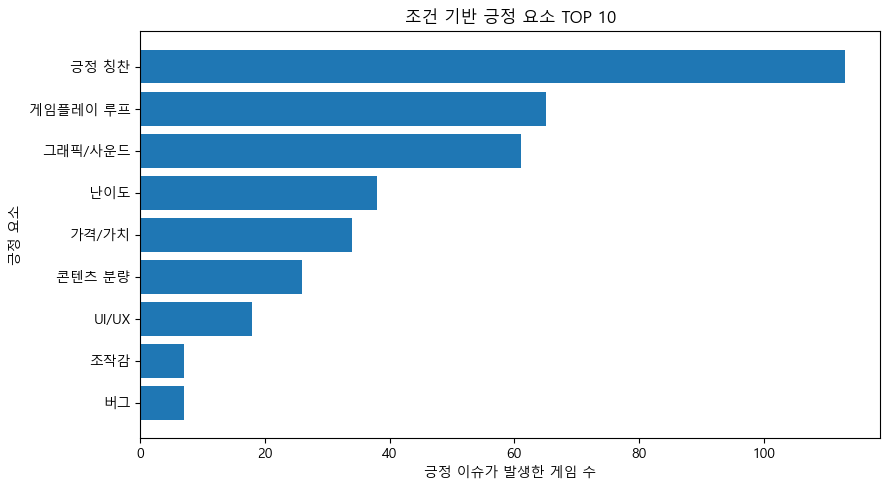

## 부정 리스크 TOP 10

구분,설명
분석 목적,입력 조건과 비슷한 게임에서 유저가 불만을 느낀 요소를 확인한다.
해석 기준,부정 발생 게임 수와 High urgency 게임 수가 많을수록 출시 전에 먼저 점검해야 할 위험 요소로 본다.
체크리스트 연결,체크리스트에서는 '출시 전 반드시 확인할 문제 후보'로 활용한다.


부정 리스크,부정 발생 게임 수,High urgency 게임 수,전체 발생 게임 수,발생 비율(%),근거 조건
UI/UX,63,35,69,73.300000,"genre | Action, play_style | Single-player 중심, price_group | 10-20, steam_tag | Pixel Graphics"
게임플레이 루프,62,42,87,80.000000,"genre | Action, play_style | Single-player 중심, price_group | 10-20, steam_tag | Pixel Graphics"
콘텐츠 분량,51,22,69,64.400000,"genre | Action, play_style | Single-player 중심, price_group | 10-20, steam_tag | Pixel Graphics"
버그,49,40,50,40.300000,"play_style | Single-player 중심, steam_tag | Pixel Graphics"
그래픽/사운드,40,35,75,68.900000,"genre | Action, play_style | Single-player 중심, price_group | 10-20, steam_tag | Pixel Graphics"
난이도,39,25,59,62.200000,"genre | Action, play_style | Single-player 중심, price_group | 10-20, steam_tag | Pixel Graphics"
가격/가치,30,18,55,45.200000,"genre | Action, play_style | Single-player 중심"
조작감,29,27,32,53.300000,"genre | Action, price_group | 10-20"


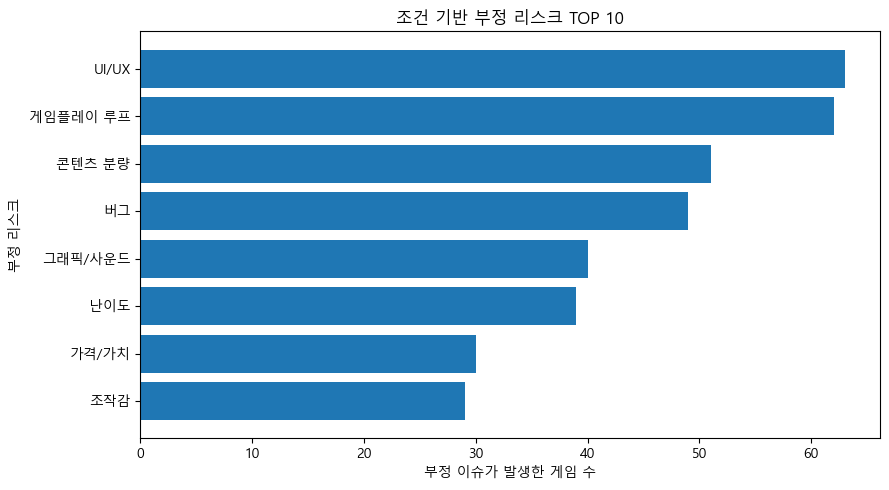

## 가격대별 반복 이슈 비교

구분,설명
분석 목적,주요 긍정 요소와 부정 리스크가 가격대별로 얼마나 반복되는지 비교한다.
해석 기준,값은 해당 가격대 게임 중 이슈가 발생한 게임 비율이다. 입력 가격대가 다른 가격대보다 어떤 강점/리스크를 가지는지 확인한다.
체크리스트 연결,"가격대에 맞는 콘텐츠 분량, 완성도, 가격 대비 가치 점검 질문을 만드는 데 사용한다."


## 가격대별 주요 긍정 요소 발생 비율(%)

condition_value,가격/가치,게임플레이 루프,그래픽/사운드,긍정 칭찬,난이도,콘텐츠 분량
free,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
0-5,27.800000,42.600000,37.000000,98.100000,25.900000,14.800000
5-10,20.500000,48.700000,41.000000,82.100000,23.100000,23.100000
10-20,37.800000,64.400000,57.800000,91.100000,37.800000,31.100000
20-40,45.500000,81.800000,54.500000,100.000000,45.500000,36.400000
40+,0.000000,100.000000,100.000000,100.000000,0.000000,0.000000


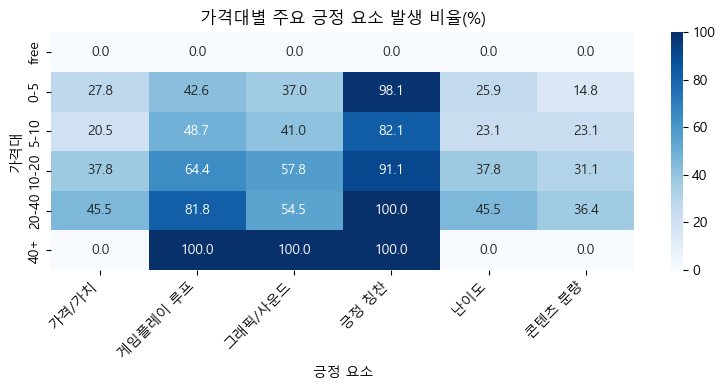

## 가격대별 주요 부정 리스크 발생 비율(%)

condition_value,UI/UX,게임플레이 루프,그래픽/사운드,난이도,버그,콘텐츠 분량
free,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000
0-5,31.500000,38.900000,27.800000,18.500000,27.800000,31.500000
5-10,48.700000,43.600000,25.600000,25.600000,43.600000,41.000000
10-20,68.900000,71.100000,42.200000,48.900000,46.700000,44.400000
20-40,81.800000,81.800000,63.600000,54.500000,63.600000,45.500000
40+,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


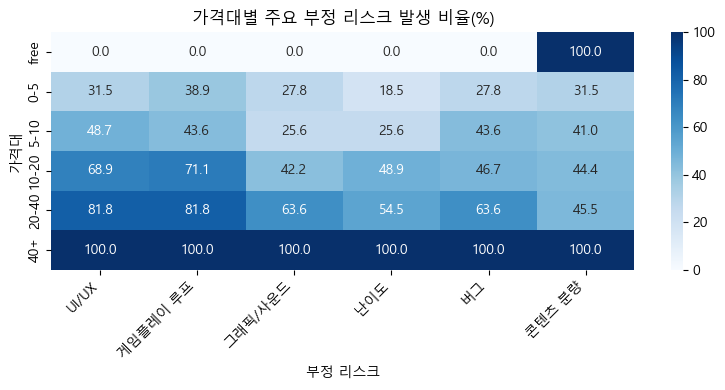

## Steam 태그별 반복 이슈 비교

구분,설명
분석 목적,입력한 Steam 태그를 가진 게임들에서 어떤 긍정 요소와 부정 리스크가 반복되는지 확인한다.
해석 기준,각 태그별로 이슈 발생 비율을 비교한다. 태그는 장르보다 더 세부적인 기대 요소를 반영한다.
체크리스트 연결,"예를 들어 Roguelike 태그라면 반복 플레이, 난이도, 밸런스 같은 점검 질문을 강화하는 근거가 된다."


## 입력 Steam 태그별 주요 긍정 요소 발생 비율(%)

condition_value,가격/가치,게임플레이 루프,그래픽/사운드,긍정 칭찬,난이도,콘텐츠 분량
Pixel Graphics,20.000000,53.300000,60.000000,86.700000,40.000000,33.300000


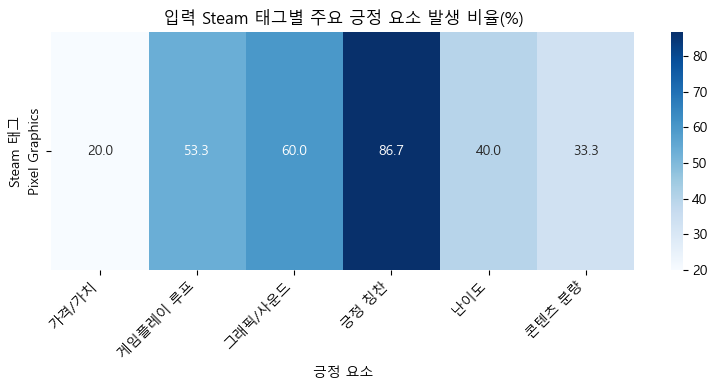

## 입력 Steam 태그별 주요 부정 리스크 발생 비율(%)

condition_value,UI/UX,게임플레이 루프,그래픽/사운드,난이도,버그,콘텐츠 분량
Pixel Graphics,66.700000,66.700000,20.000000,33.300000,33.300000,33.300000


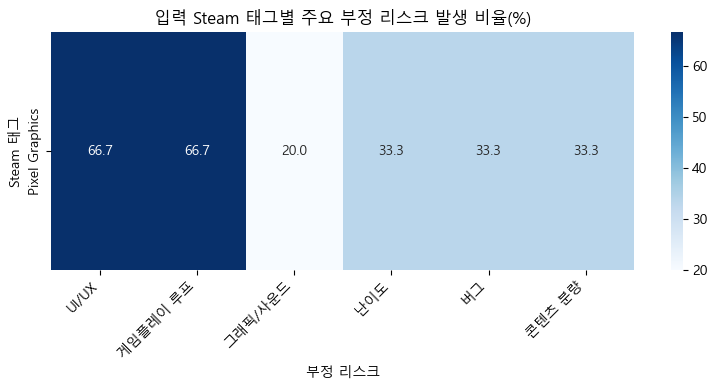

## Steam 태그 DNA 참고 정보

구분,설명
분석 목적,"조원 EDA에서 사용한 방식처럼, 입력한 Steam 태그가 성과 상위권 게임에서도 얼마나 나타나는지 확인한다."
해석 기준,HH/HM/MH는 성과가 비교적 좋은 게임 그룹을 뜻한다. 상위권 비율은 태그의 참고 특성일 뿐 성공 보장으로 해석하지 않는다.
체크리스트 연결,"태그 자체의 성공 가능성을 말하는 용도가 아니라, 해당 태그를 가진 게임의 기대 요소와 점검 방향을 보조적으로 해석하는 데 사용한다."


입력 태그,매칭 태그,전체 게임 수,HH 게임 수,HM 게임 수,MH 게임 수,상위권 게임 수,상위권 비율(%),해석 메모
Roguelike,Rogue-like,1136,149,29,267,445,39.200000,"'Roguelike' 태그는 성과 등급 데이터에서 1136개 게임에 나타났고, 그중 성과 상위권(HH/HM/MH) 게임은 445개(39.2%)다. 이는 성공 보장이 아니라 태그 조건 해석용 참고 정보다."
Pixel Graphics,Pixel Graphics,2197,233,34,566,833,37.900000,"'Pixel Graphics' 태그는 성과 등급 데이터에서 2197개 게임에 나타났고, 그중 성과 상위권(HH/HM/MH) 게임은 833개(37.9%)다. 이는 성공 보장이 아니라 태그 조건 해석용 참고 정보다."


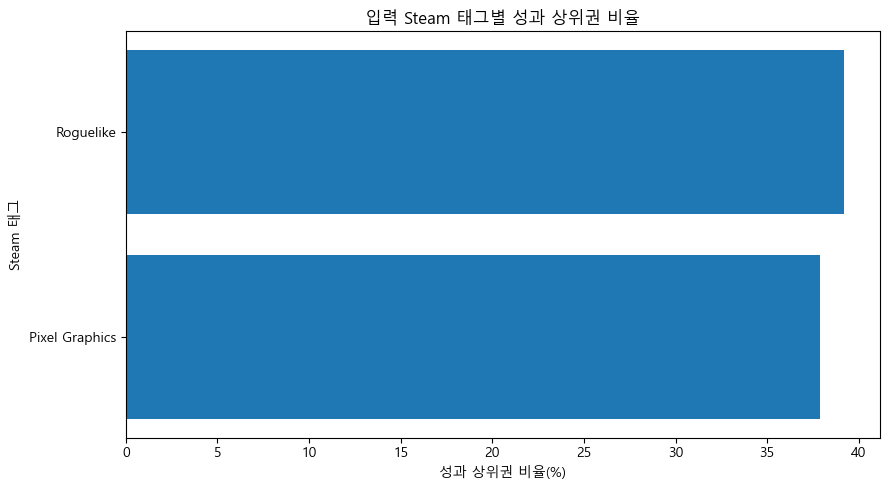

## 플레이 방식별 반복 이슈 비교

구분,설명
분석 목적,싱글 중심 게임과 멀티/협동 요소 포함 게임에서 반복되는 긍정 요소와 부정 리스크 차이를 확인한다.
해석 기준,플레이 방식별 이슈 발생 비율을 비교해 어떤 구조에서 어떤 강점/문제가 더 자주 나타나는지 본다.
체크리스트 연결,"싱글 게임은 콘텐츠 흐름과 몰입감, 멀티/협동 게임은 매칭·동기화·협동 경험 같은 점검 항목으로 연결할 수 있다."


## 플레이 방식별 주요 긍정 요소 발생 비율(%)

condition_value,가격/가치,게임플레이 루프,그래픽/사운드,긍정 칭찬,난이도,콘텐츠 분량
Single-player 중심,27.400000,52.400000,49.200000,91.100000,30.600000,21.000000
멀티/협동 요소 포함,40.700000,59.300000,29.600000,92.600000,25.900000,33.300000


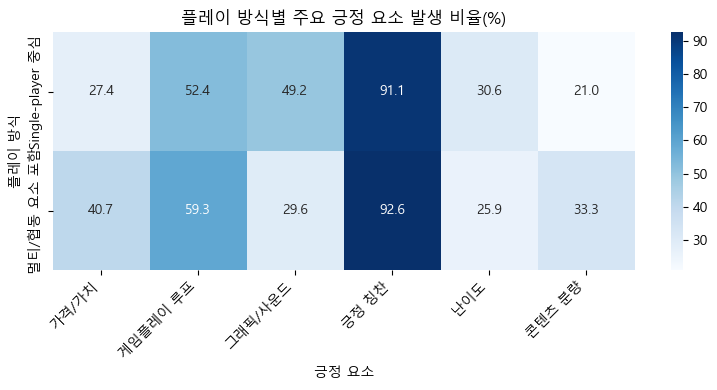

## 플레이 방식별 주요 부정 리스크 발생 비율(%)

condition_value,UI/UX,게임플레이 루프,그래픽/사운드,난이도,버그,콘텐츠 분량
Single-player 중심,50.800000,50.000000,32.300000,31.500000,39.500000,41.100000
멀티/협동 요소 포함,51.900000,66.700000,44.400000,37.000000,44.400000,33.300000


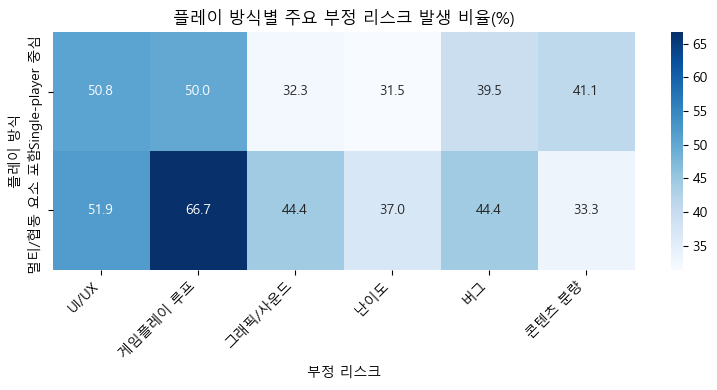

## 전체 게임 기준 반복 이슈

구분,설명
분석 목적,전체 분석 대상 게임에서 공통적으로 많이 반복된 긍정 요소와 부정 리스크를 확인한다.
해석 기준,"조건별 이슈가 전체 게임에서도 흔한 문제인지, 특정 조건에서만 두드러지는 문제인지 비교하는 기준선으로 본다."
체크리스트 연결,LLM이 조건별 이슈를 과대해석하지 않도록 전체 기준과 비교하는 보조 근거로 사용한다.


이슈,발생 게임 수,발생 비율(%),긍정 발생 게임 수,부정 발생 게임 수,High urgency 게임 수,우선순위
긍정 칭찬,138,91.400000,138,0,45,상
게임플레이 루프,106,70.200000,81,80,56,상
그래픽/사운드,89,58.900000,69,52,41,상
UI/UX,85,56.300000,24,77,46,상
콘텐츠 분량,85,56.300000,35,60,27,상
난이도,76,50.300000,45,49,33,상
가격/가치,68,45.000000,45,33,20,상
버그,62,41.100000,7,61,47,상


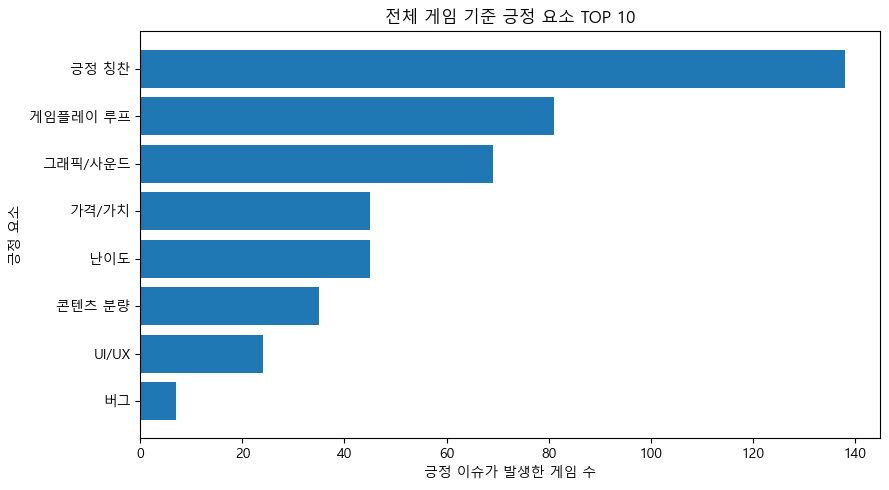

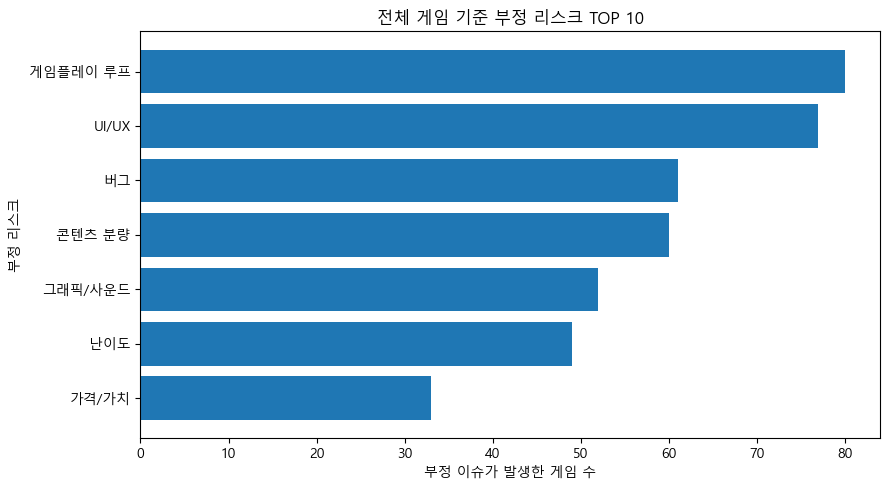

In [17]:
# ============================================================
# 체크리스트 생성 전 조건 기반 분석 출력
# ============================================================
# 각 분석 설명은 display_pre_checklist_dashboard() 내부 출력 함수에서 함께 표시된다.

pre_checklist_dashboard_result = display_pre_checklist_dashboard(
    selected_evidence=selected_evidence,
    condition_issue_summary=condition_issue_summary,
    overall_issues=overall_issues,
    tag_dna_summary=tag_dna_summary,
    user_condition=USER_CONDITION,
)

# 15. 출시 전 개발 체크리스트 표 출력

## 출시 전 개발 체크리스트

구분,설명
분석 목적,LLM이 조건 기반 근거를 바탕으로 생성한 최종 출시 전 점검표를 확인한다.
해석 기준,"체크 질문은 개발자가 출시 전에 실제로 확인해야 하는 항목이며, 우선순위는 상·중·하로 나뉜다."
체크리스트 연결,보고서나 발표에서는 이 표를 최종 결과물로 제시하면 된다.


항목,내용
조건 요약,"Action 장르, 10-20달러 가격대, Roguelike 및 Pixel Graphics 태그를 포함한 Single-player 중심의 게임입니다."
데이터 요약,"총 124개의 Single-player 게임 리뷰 데이터를 분석하였으며, 각 조건별로 반복되는 핵심 이슈들을 추출하였습니다."
Steam 태그 DNA 참고,"'Roguelike'와 'Pixel Graphics' 태그는 성과 상위권 게임에서 각각 약 38~39%의 비중으로 나타나며, 해당 장르의 대중적인 선호도를 보여줍니다."


구분,체크 질문,우선순위,근거 이슈,근거,확인 방법
기술 안정성,"게임 실행 중 크래시, 진행 불가 버그, 저장 오류 등 치명적인 기술적 결함이 없는가?",상,버그,"Single-player 게임에서 버그는 124개 게임 중 50개에서 나타났으며, 부정적 맥락이 49개로 매우 높고 High urgency 이슈로 분류됨.",QA 테스트를 통해 주요 경로 및 예외 상황에서의 크래시 여부 전수 조사.
핵심 루프,"초반 30분 내에 게임의 핵심 재미(Action/Roguelike)를 경험할 수 있으며, 반복 플레이가 지루하지 않은가?",상,게임플레이 루프,"Action 장르 및 10-20달러 가격대 게임에서 80% 이상의 높은 빈도로 언급되며, 부정적 맥락이 긍정적 맥락보다 많음.",FGT(포커스 그룹 테스트)를 통해 플레이어가 게임의 핵심 재미를 느끼는 시점과 반복 플레이 의지를 측정.
조작감,"이동, 공격, 회피 등 캐릭터의 조작이 즉각적이고 의도한 대로 반응하는가?",상,조작감,"Action 장르 게임에서 51.6%의 빈도로 언급되며, 부정적 맥락이 29개로 긍정적 맥락(7개)보다 압도적으로 많음.",입력 지연(Input Lag) 테스트 및 다양한 컨트롤러 환경에서의 조작감 검증.
UI/UX,"메뉴 탐색, 인벤토리 관리, 정보 전달이 직관적이며 플레이 흐름을 방해하지 않는가?",중,UI/UX,"Action 장르 및 10-20달러 가격대에서 50% 이상의 빈도로 언급되며, 부정적 맥락이 매우 높음.",사용성 테스트(Usability Test)를 통해 플레이어가 메뉴를 찾는 데 어려움을 겪는지 관찰.
난이도,"게임의 난이도 곡선이 적절하며, 플레이어가 불합리하다고 느끼는 구간이 없는가?",중,난이도,"Action 장르에서 61.3%의 빈도로 언급되며, 부정적 맥락과 긍정적 맥락이 팽팽하게 대립함.",다양한 숙련도의 테스터를 통해 난이도 밸런스 및 튜토리얼의 적절성 확인.
콘텐츠 분량,가격 대비 제공되는 콘텐츠의 양과 질이 플레이어의 기대치를 충족하는가?,중,콘텐츠 분량,"10-20달러 가격대에서 64.4%의 빈도로 언급되며, 부정적 맥락이 긍정적 맥락보다 많음.",플레이 타임 측정 및 가격 대비 콘텐츠 밀도에 대한 내부 평가 수행.
그래픽/사운드,"Pixel Graphics 스타일이 게임의 분위기와 잘 어우러지며, 사운드 효과가 타격감을 충분히 전달하는가?",하,그래픽/사운드,"Pixel Graphics 태그 게임에서 66.7%의 빈도로 언급되며, 긍정적 맥락이 부정적 맥락보다 많음.",시각적 가독성 테스트 및 사운드 이펙트가 액션의 피드백을 적절히 제공하는지 확인.


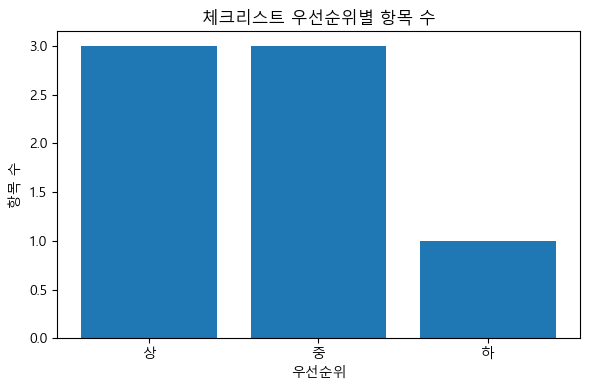

## 해석 시 주의사항

구분,설명
분석 목적,LLM 체크리스트를 해석할 때 주의해야 할 한계와 조건을 확인한다.
해석 기준,표본 수가 적거나 근거가 약한 조건은 단정적으로 해석하지 않는다.
체크리스트 연결,최종 보고서에서 분석 한계 또는 주의사항 문장으로 사용할 수 있다.


주의사항
본 체크리스트는 제공된 데이터 내에서 반복적으로 나타난 이슈를 바탕으로 작성되었습니다. 특정 이슈가 발생하지 않는다고 해서 게임의 성공이 보장되는 것은 아닙니다.
"'긍정 칭찬' 항목은 데이터상 높은 비중을 차지하나, 이는 게임의 완성도와 직결되는 요소이므로 개발 단계에서 지속적인 피드백을 통해 유지해야 합니다."
"Steam 태그 DNA 정보는 참고용이며, 해당 태그를 사용한다고 해서 반드시 성과가 보장되는 것은 아닙니다."


## 최종 요약

구분,설명
분석 목적,LLM이 생성한 체크리스트의 핵심 결론을 짧게 확인한다.
해석 기준,입력 조건에서 가장 우선적으로 점검해야 할 방향을 요약한 문장으로 읽는다.
체크리스트 연결,발표용 마무리 문장이나 보고서 요약에 활용할 수 있다.


본 체크리스트는 Action Roguelike 게임 개발 시 플레이어들이 가장 민감하게 반응하는 게임플레이 루프, 조작감, 버그, UI/UX 문제를 중심으로 구성되었습니다. 특히 'Action' 장르와 'Roguelike' 요소가 결합된 경우, 반복적인 플레이 경험의 질과 기술적 안정성이 성공의 핵심 요소로 판단됩니다.

In [18]:
# ============================================================
# 출시 전 개발 체크리스트 출력
# ============================================================
# 출력 함수는 3-1. 출력 함수 모음에 정리해두었다.
# 여기서는 LLM 결과가 있을 때 함수만 호출한다.

if checklist_result_dict is not None:
    checklist_table_df = display_checklist_result(checklist_result_dict)
else:
    print("LLM 결과가 없어 체크리스트 표를 출력하지 않았습니다.")
